# A-RoF ARVTDNN-DPD

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado"
file_path    = project_path + r"\DPD"
sys.path.append(project_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch as th

from torch                    import nn
from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, upsample, pulseShape, decimate, finddelay
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W
from optic_private.dsp.core   import calcACLR
from optic_private.torchUtils import fitFilterNN

from dpd.nn                   import NN_training
from dpd.utils                import power_amplifier, clip_complex
from dpd.plots                import calc_per_carrier

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [124]:
device = "cuda"
includeMemory = True

# Parâmetros de modulação
modOrder = 64                          # Ordem da modulação
modType  = 'qam'                       # Tipo de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 32                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                 # Tam. da FFT
paramOFDM.G    = 32                  # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs  = Rs * SpS                                                         # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 100
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [125]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [126]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 27.74 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.87 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [127]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 7.5e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

#### 2.1 Sinal RF

In [128]:
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )

gain_pre_MZM = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input: {10*np.log10(1e3*signal_power(sigTx_RF)):.3f} dBm")

Power at MZM's input: 17.000 dBm


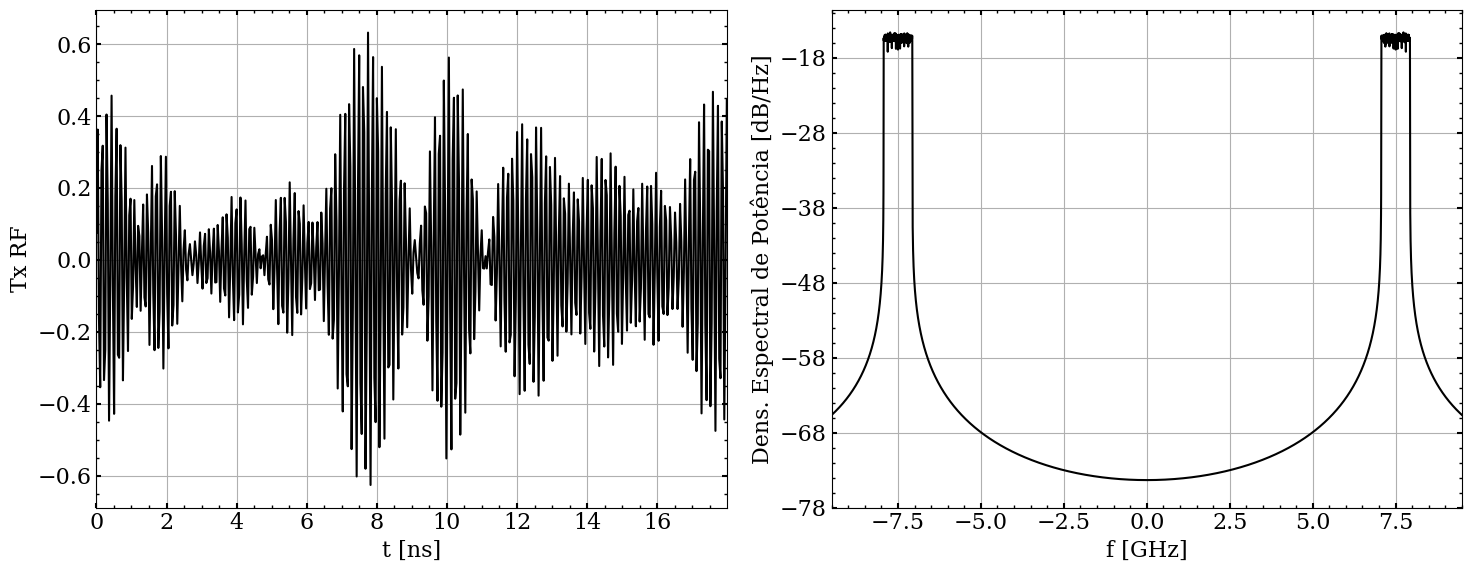

In [129]:

indx = np.arange(0, 500)

fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTx_RF[indx], "k")
axs[1].psd(sigTx_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.2 Sinal óptico

In [130]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

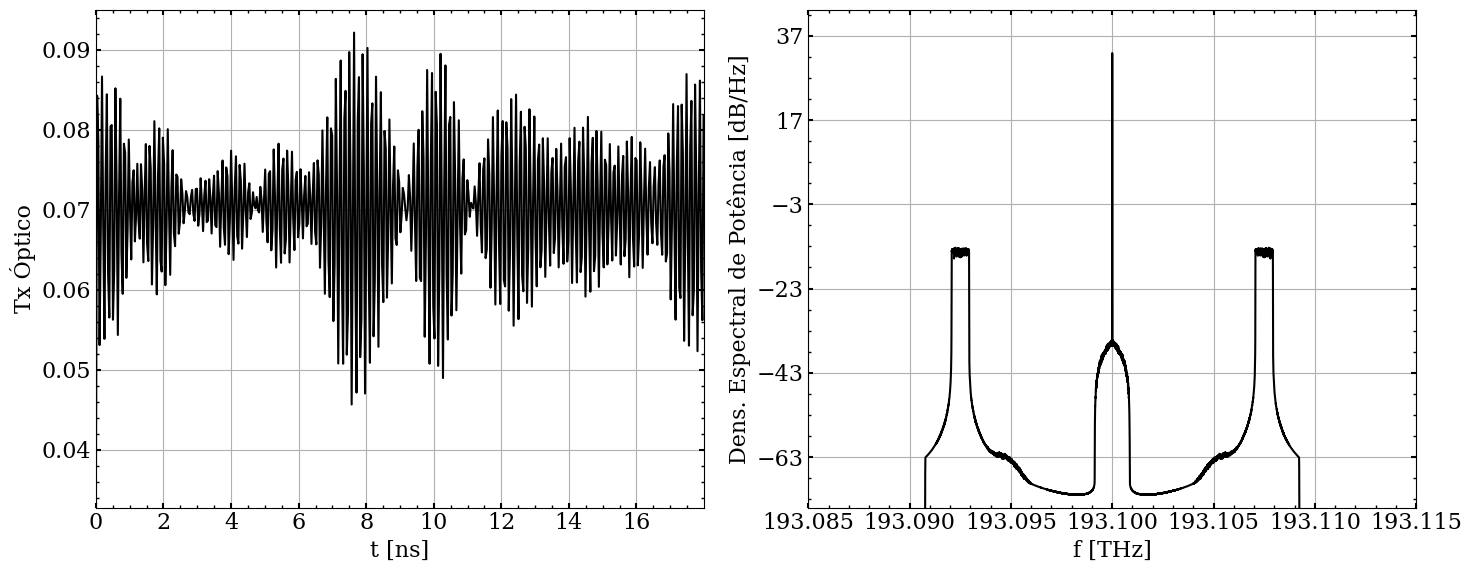

In [131]:
indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTxo[indx], "k")
axs[1].psd(np.abs(sigTxo), Fs = Fs/1e12, Fc = paramChannel.Fc/1e12, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx Óptico")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-0.015 + paramChannel.Fc/1e12, 0.015 + paramChannel.Fc/1e12)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.3 Sinal elétrico (fotocorrente)

In [132]:
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

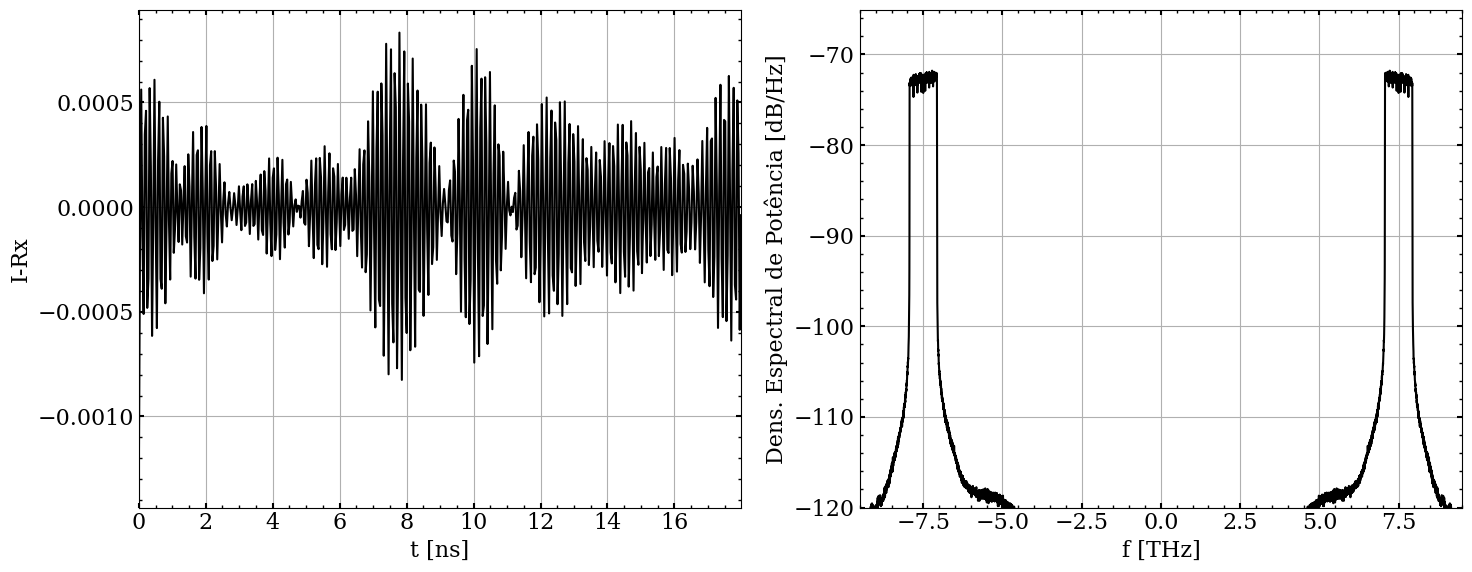

In [133]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_Rx[indx], "k")
axs[1].psd(I_Rx, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-Rx")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -60, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.4 Sinal elétrico pós-FPF

In [134]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

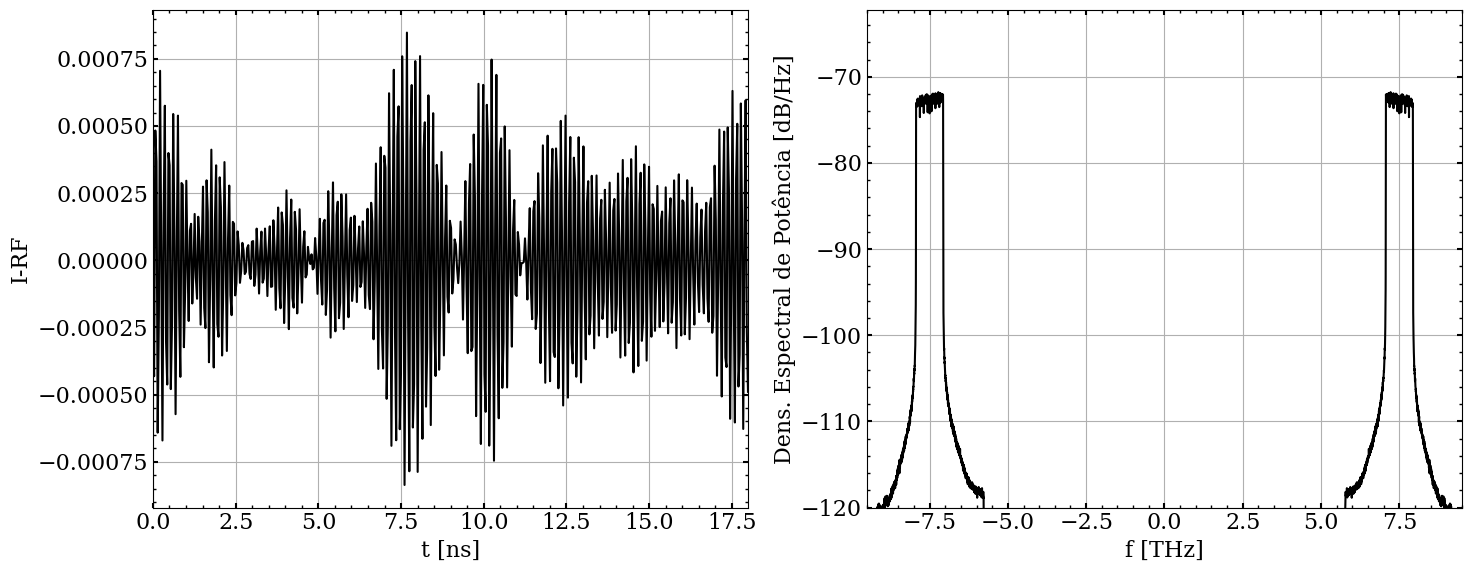

In [135]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_RF[indx], "k")
axs[1].psd(I_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -60, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.5 Sinal elétrico pós-PA

In [136]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)

alpha = 1  # dB
theta = 5  # degrees

IQ_imb = 1 # 10**(alpha / 10) * np.exp(1j*theta * pi/180)
sigRx = sigRx.real + 1j*sigRx.imag * IQ_imb

gain_pre_PA = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= gain_pre_PA

print(f"Power at PA's input: {10*np.log10(1e3*signal_power(sigRx)):.3f} dBm")

sigRx = power_amplifier(sigRx)

sigRx_PA = sigRx.copy()
sigRx_PA = pnorm(sigRx_PA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

Power at PA's input: 5.000 dBm


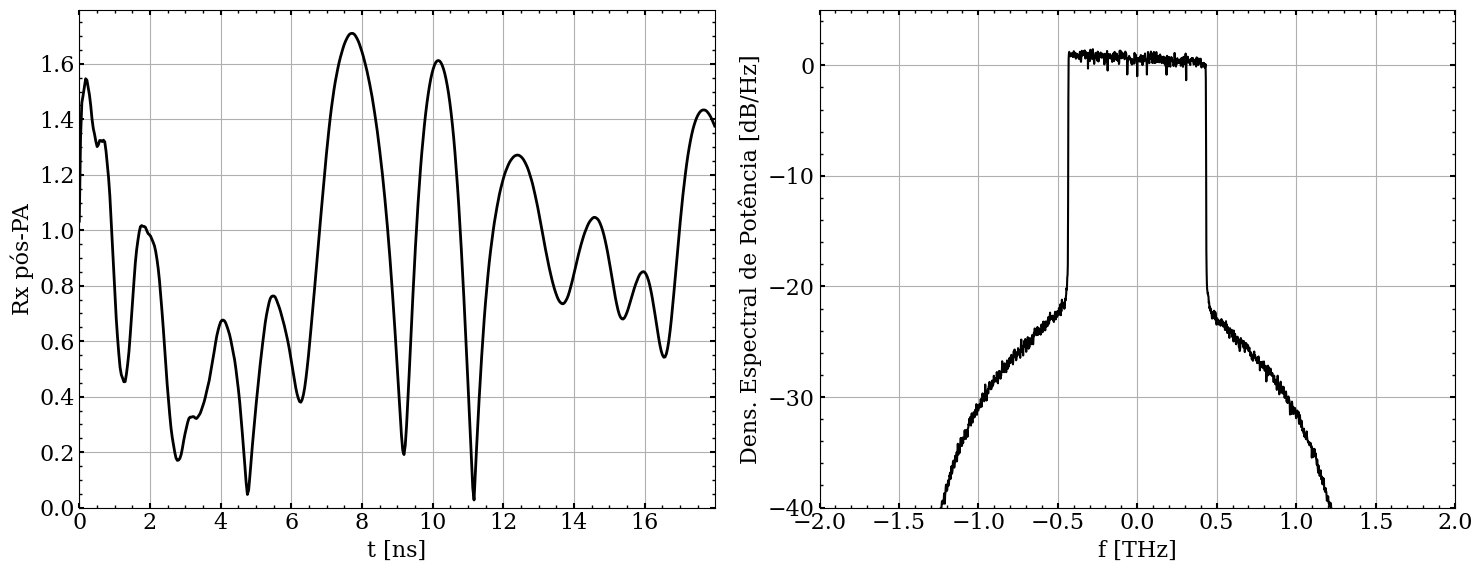

In [137]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigRx_PA[indx]), "k", lw = 2)
axs[1].psd(sigRx_PA, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Rx pós-PA")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-40, 5)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-40, 5, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()


In [138]:
delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

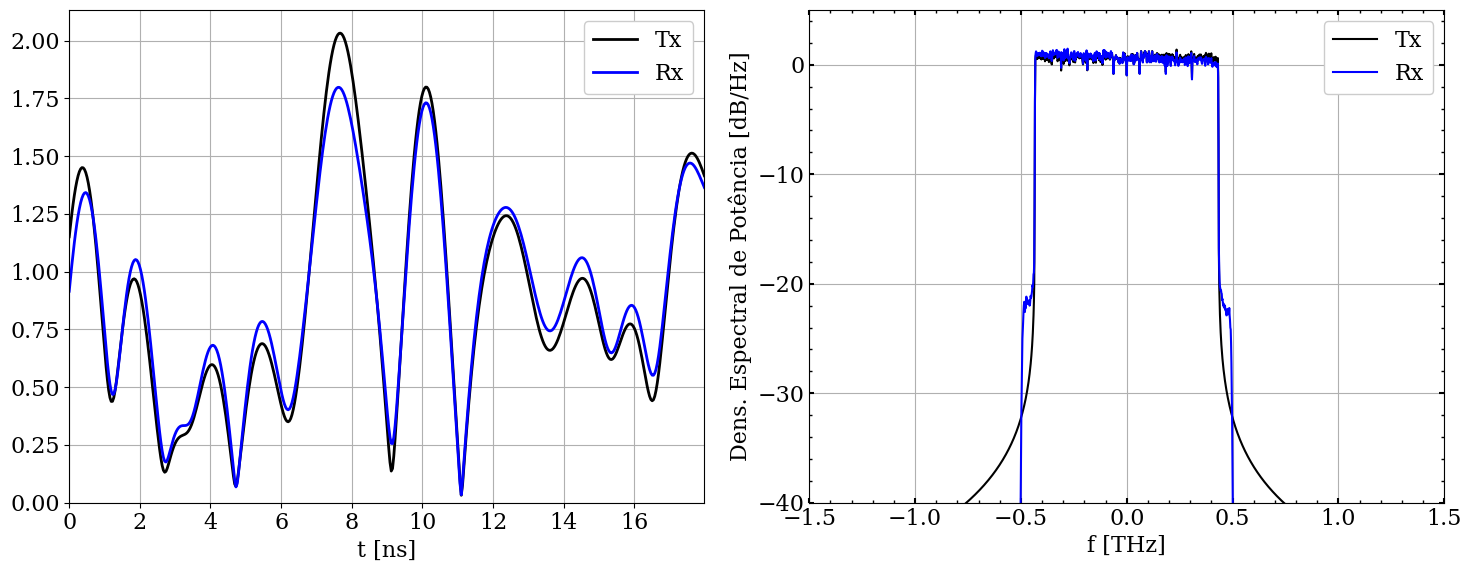

In [139]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigTx))[indx], label = "Tx", lw = 2, color = "k")
axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigRx))[indx], label = "Rx", lw = 2, color = "b")

axs[1].psd(pnorm(sigTx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Tx", color = "k")
axs[1].psd(pnorm(sigRx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Rx", color = "b")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].legend(framealpha = 1)

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-40, 5)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-40, 5, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1)

plt.tight_layout()
plt.show()

#### 2.6 Performance

In [140]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00388 
SNR = 21.206 dB


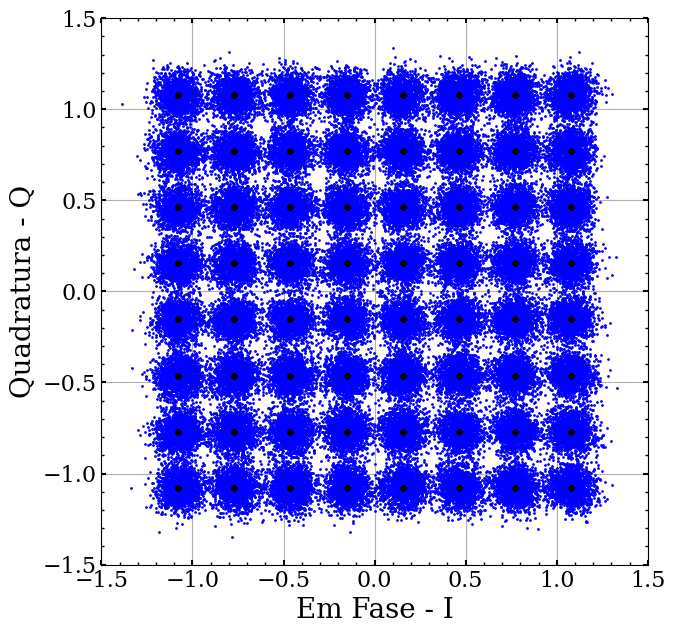

In [141]:
discard = Ni
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx, modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadratura - Q", fontsize = 20)
axs.set_xlabel("Em Fase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.grid()

plt.tight_layout()
#plt.savefig("constelacao_noDPD.png")

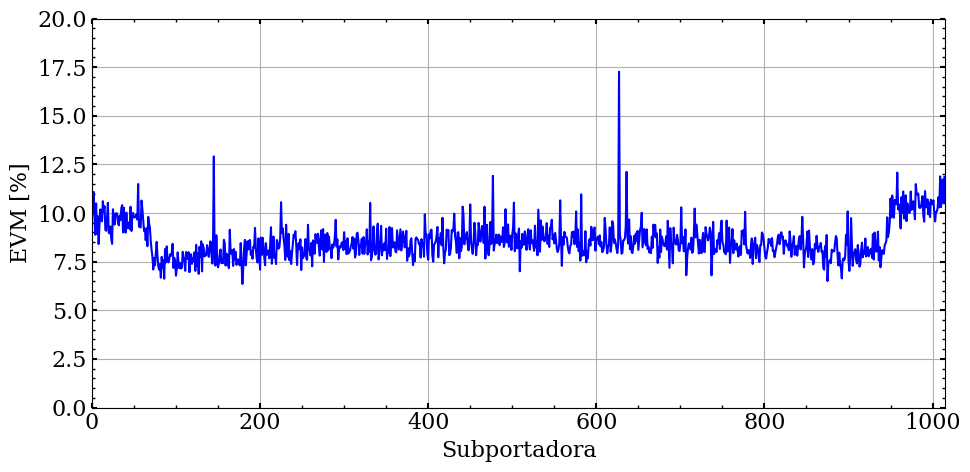

In [142]:
_, SNR_per_carrier, EVM_per_carrier = calc_per_carrier(symbTx, symbRx, Ni, numOFDMframes)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(EVM_per_carrier, color = "b")
axs.set_xlim(0, Ni)
axs.set_ylim(0, 20)
axs.set_ylabel("EVM [%]")
axs.set_xlabel("Subportadora")
axs.grid()
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.tight_layout()

### 3 Identificação do canal

In [143]:
SpS_nn = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_nn

hlp = firwin(numtaps, SpS_nn*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

In [144]:
delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

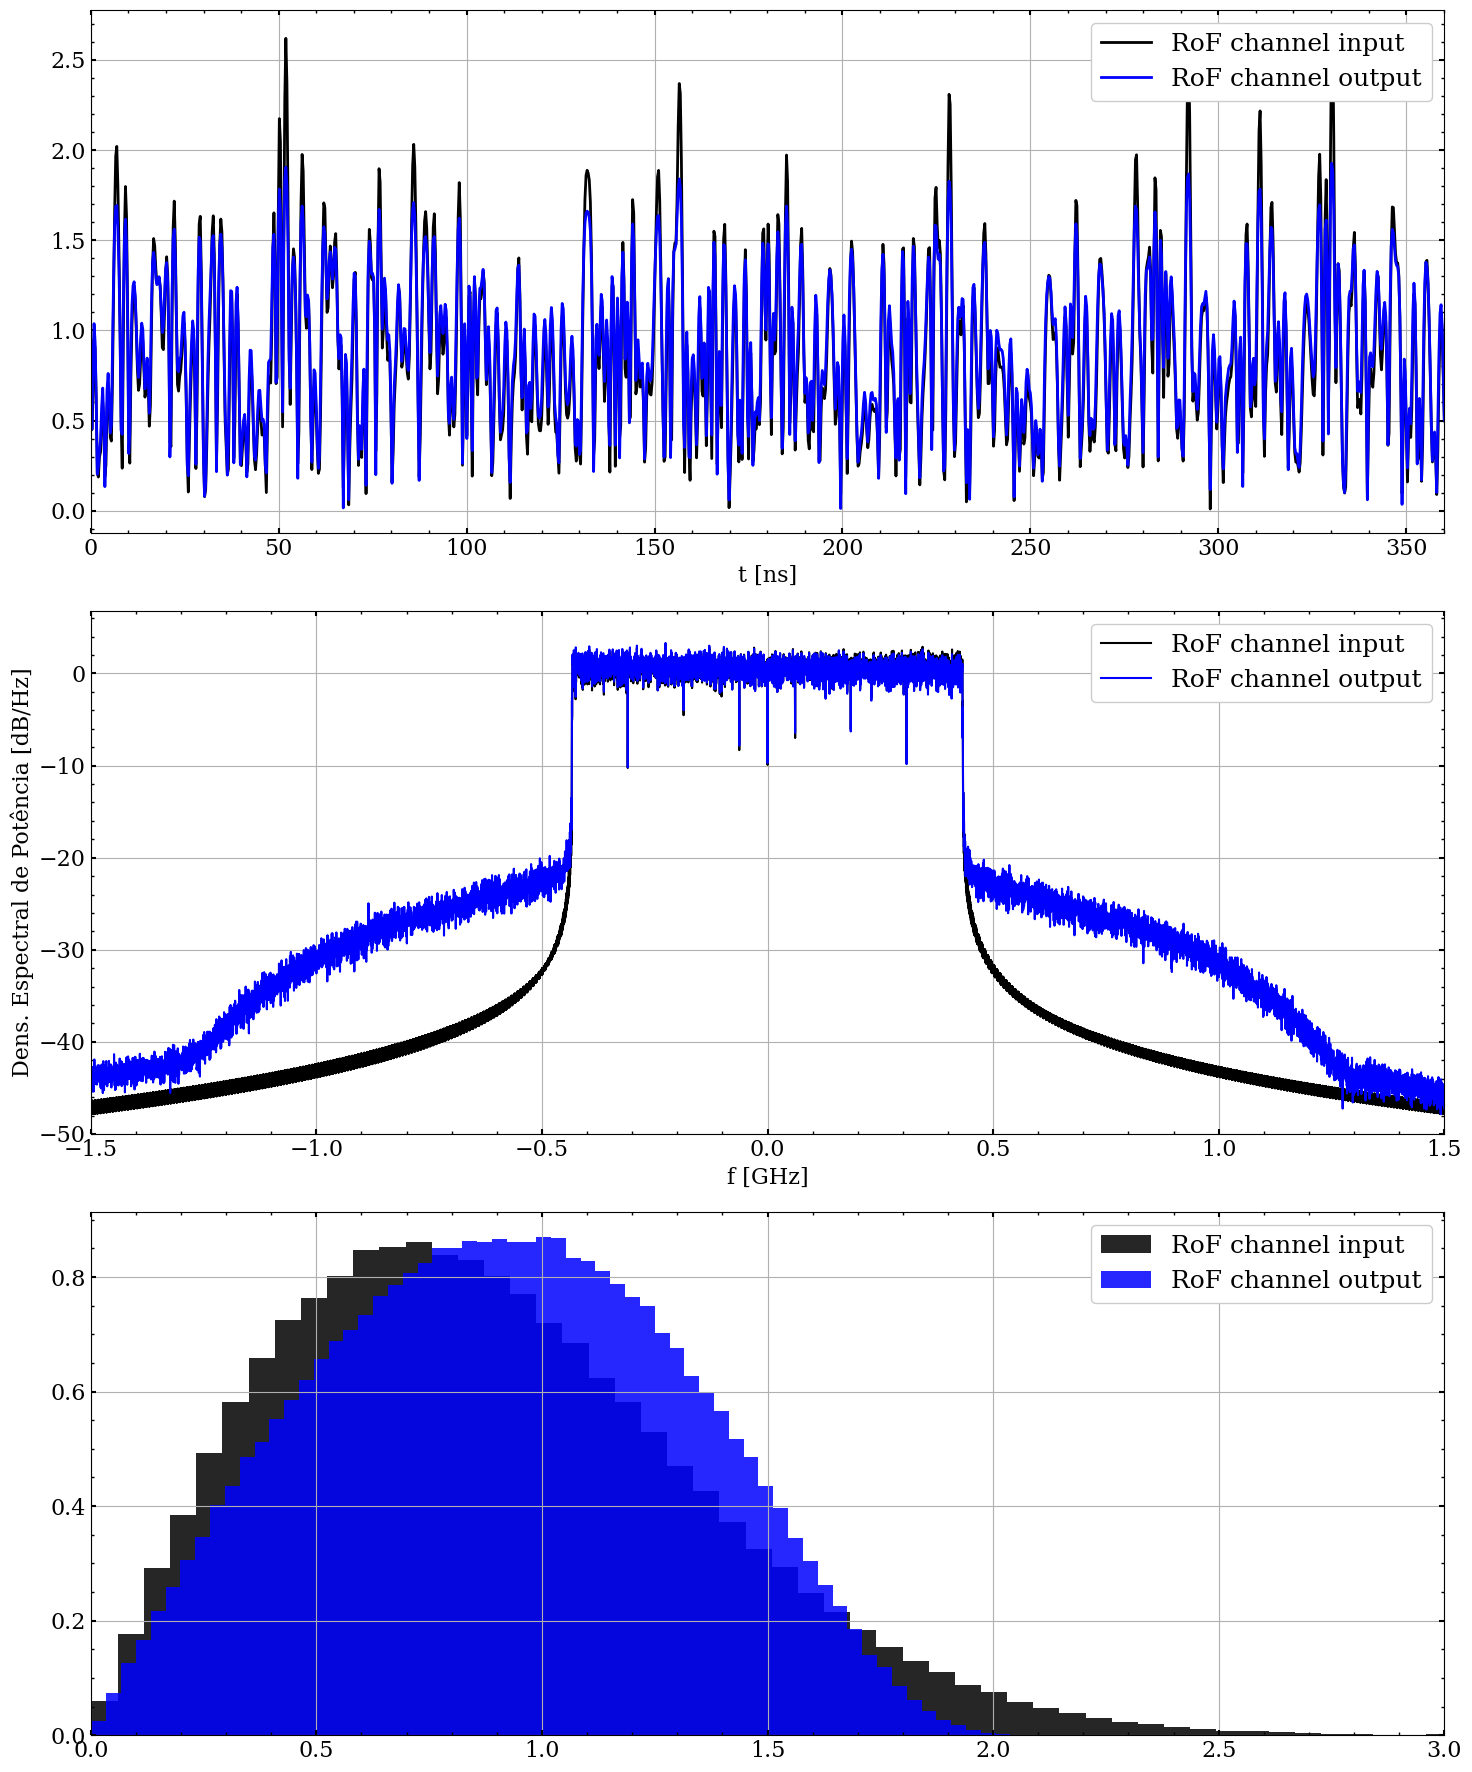

In [145]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_nn)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "RoF channel input")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), "b", lw = 2, label = "RoF channel output")

axs[1].psd(sigRef, Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "RoF channel input")
axs[1].psd(sigIn, Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "RoF channel output")

axs[0].set_xlim(0, np.max(t[indx]*1e9))
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), color = "k", density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(np.abs(sigIn), color = "b", density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

In [146]:
sigRef = th.from_numpy(sigRef).to(device).type(th.complex64)
sigIn  = th.from_numpy(sigIn).to(device).type(th.complex64)

In [147]:
paramRoF = parameters()

N = 50_000 

paramRoF.divByL = 1
paramRoF.trainTestFrac = 0.75
paramRoF.batch_size = 1_000
paramRoF.shuffle = False
paramRoF.includeMemory = includeMemory
paramRoF.Ntaps = 2
paramRoF.K = 0
paramRoF.augment = False

paramRoF.layers = [2*paramRoF.Ntaps, 35, 2]
paramRoF.device = device
paramRoF.lr = 5e-3
paramRoF.epochs = 500
paramRoF.activation = "relu"
paramRoF.pgrsBar = True
paramRoF.directLearn = False

paramRoF.envelope = False

RoFChannel_model, trainLoss, testLoss = NN_training(sigRef[0:N], sigIn[0:N], paramRoF)

  0%|          | 0/500 [00:00<?, ?it/s]

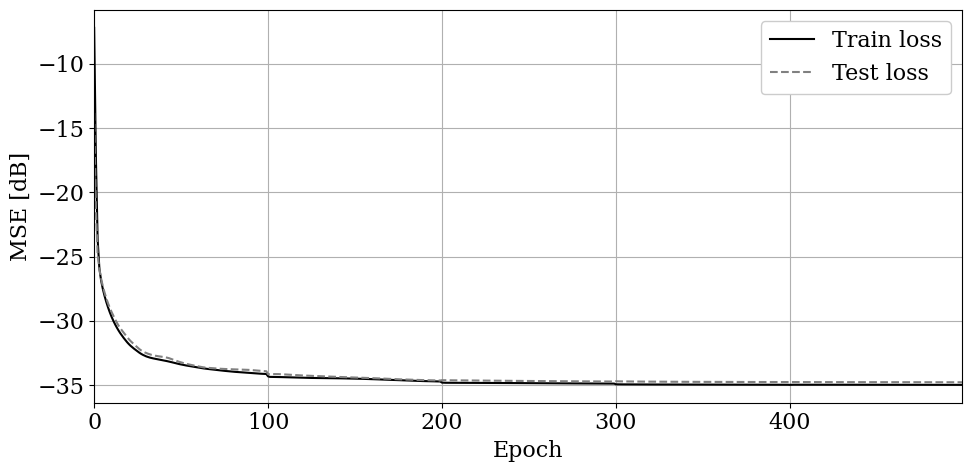

In [148]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramRoF.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [149]:
if includeMemory:
    sig_nn = fitFilterNN(sigRef, RoFChannel_model, paramRoF.Ntaps, paramRoF.K, 1, 100, augment = paramRoF.augment, prgsBar = True)
else:
    with th.no_grad():
        sig_nn = th.view_as_complex(RoFChannel_model(th.view_as_real(sigRef).to(th.float32)))

100%|████████████████████████████████████████████████████████████████████████████| 4224/4224 [00:00<00:00, 4447.35it/s]


MSE = -31.895 dB


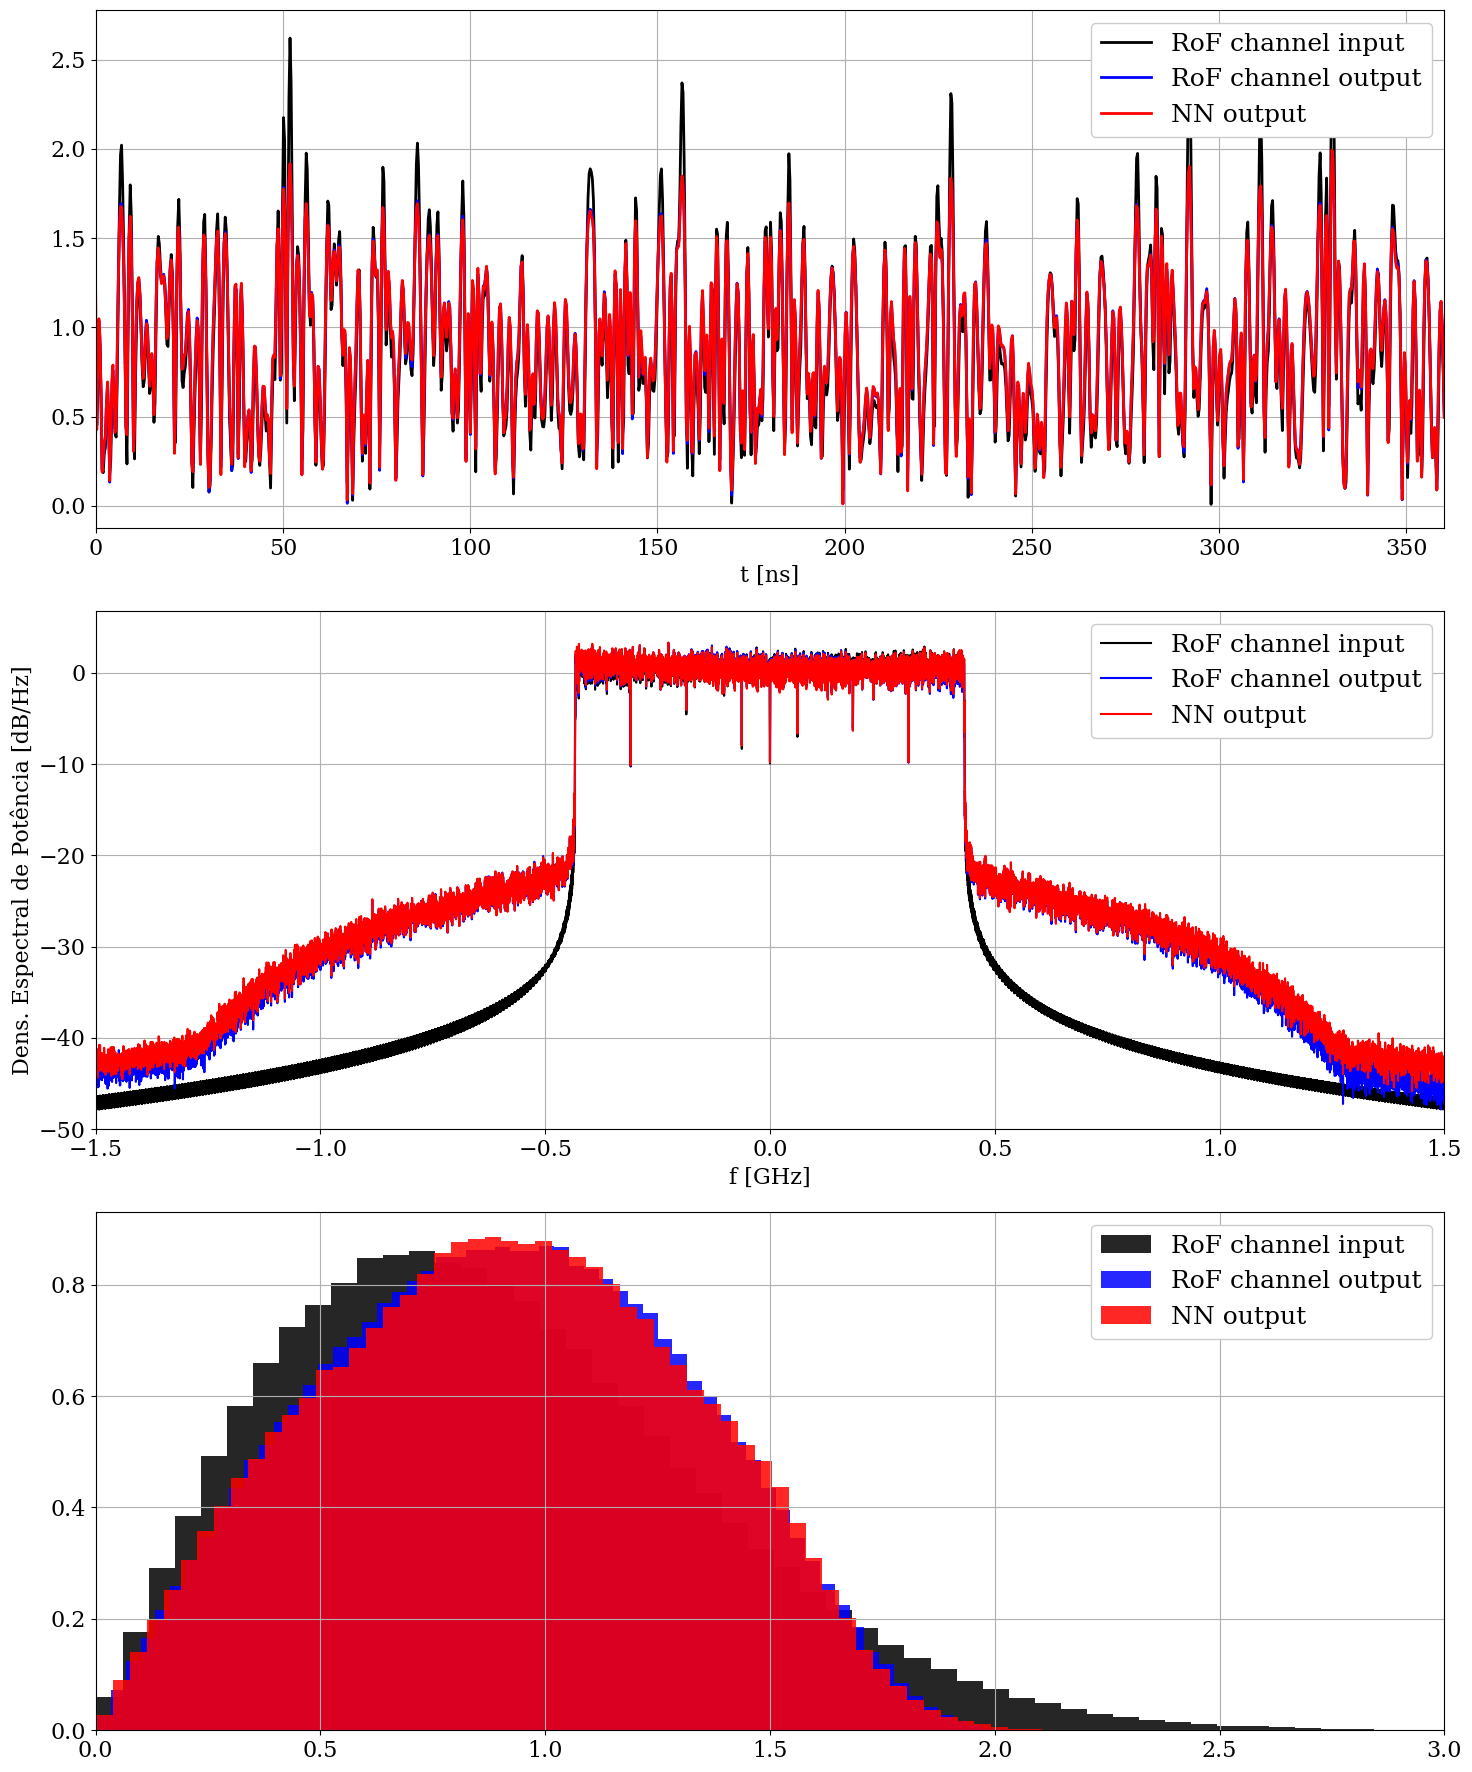

In [150]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

MSE = 10*th.log10(th.mean(th.abs(sigIn - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), lw = 2, color = "k", label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), lw = 2, color = "b", label = "RoF channel output")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sig_nn.cpu().numpy()[indx]), lw = 2, color = "r", label = "NN output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "RoF channel output")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "NN output")

axs[0].set_xlim(0, np.max(t.cpu().numpy()[indx])*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, color = "k", label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, color = "b", label = 'RoF channel output', alpha = 0.85)
axs[2].hist(th.abs(sig_nn).detach().cpu().numpy(), density = True, bins = 64, color = "r",label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

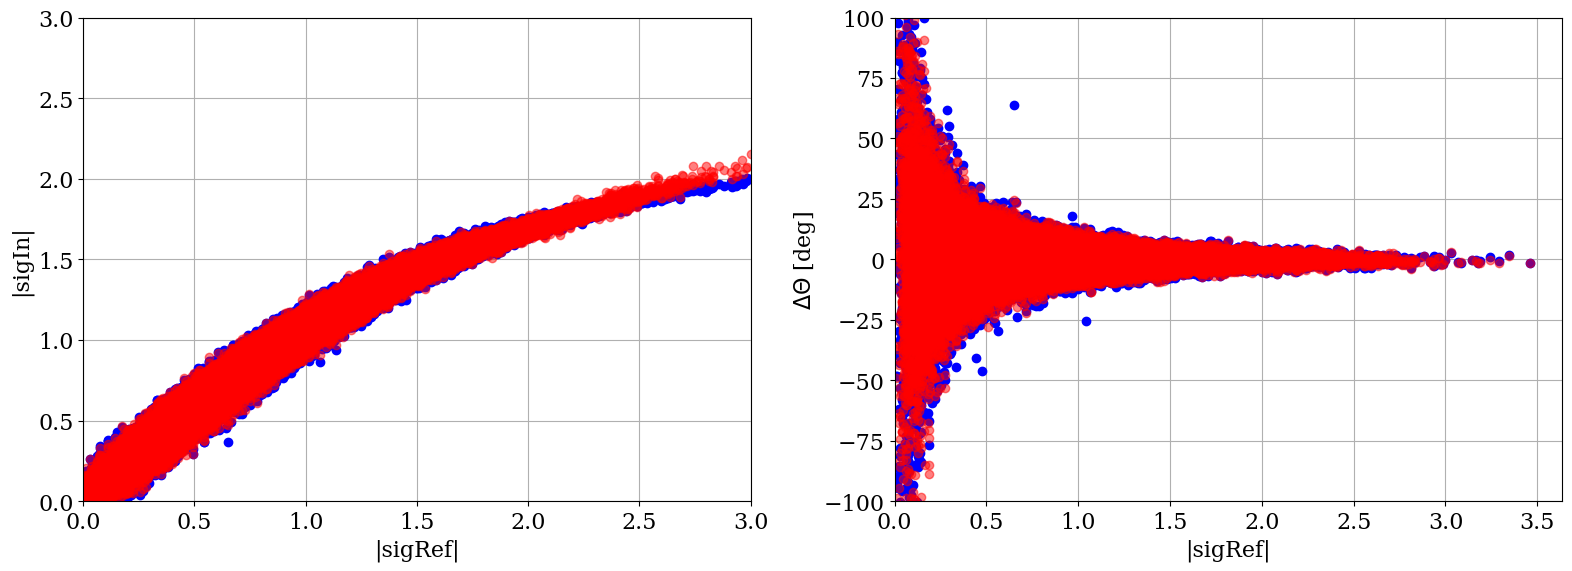

In [151]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), np.abs(sigIn[0:n_pts].detach().cpu().numpy()), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), np.abs(sig_nn[0:n_pts].detach().cpu().numpy()), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), (np.angle(sigIn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), (np.angle(sig_nn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [152]:
paramILA = parameters()

N = 100_000

paramILA.divByL = 1
paramILA.trainTestFrac = 0.75
paramILA.batch_size = 1_000
paramILA.shuffle = False
paramILA.includeMemory = includeMemory
paramILA.Ntaps = 4
paramILA.K = 2
paramILA.augment = True

paramILA.layers = [(paramILA.K + 2)*paramILA.Ntaps, 35, 2]

paramILA.device = device
paramILA.lr = 5e-3
paramILA.epochs = 500
paramILA.activation = "relu"
paramILA.pgrsBar = True
paramILA.directLearn = False

paramILA.envelope = False

DPD_indirectLearn, trainLoss, testLoss = NN_training(sigIn[0:N], sigRef[0:N], paramILA)

  0%|          | 0/500 [00:00<?, ?it/s]

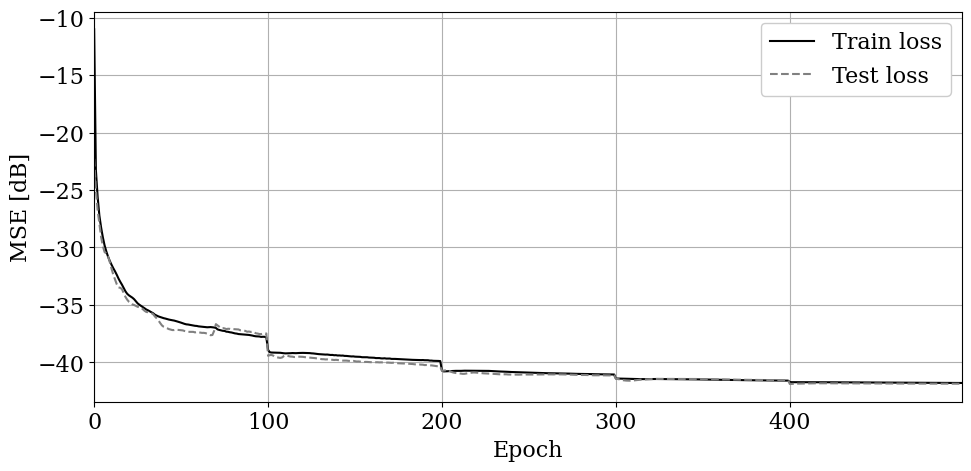

In [153]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramILA.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [154]:
if includeMemory:
    sig_nn = fitFilterNN(sigIn, DPD_indirectLearn, paramILA.Ntaps, paramILA.K, 1, 100, augment = paramILA.augment, prgsBar = True)
else:
    with th.no_grad():
        sig_nn = th.view_as_complex(DPD_indirectLearn(th.view_as_real(sigIn).to(th.float32)))

100%|████████████████████████████████████████████████████████████████████████████| 4224/4224 [00:01<00:00, 4043.86it/s]


MSE = -38.611 dB


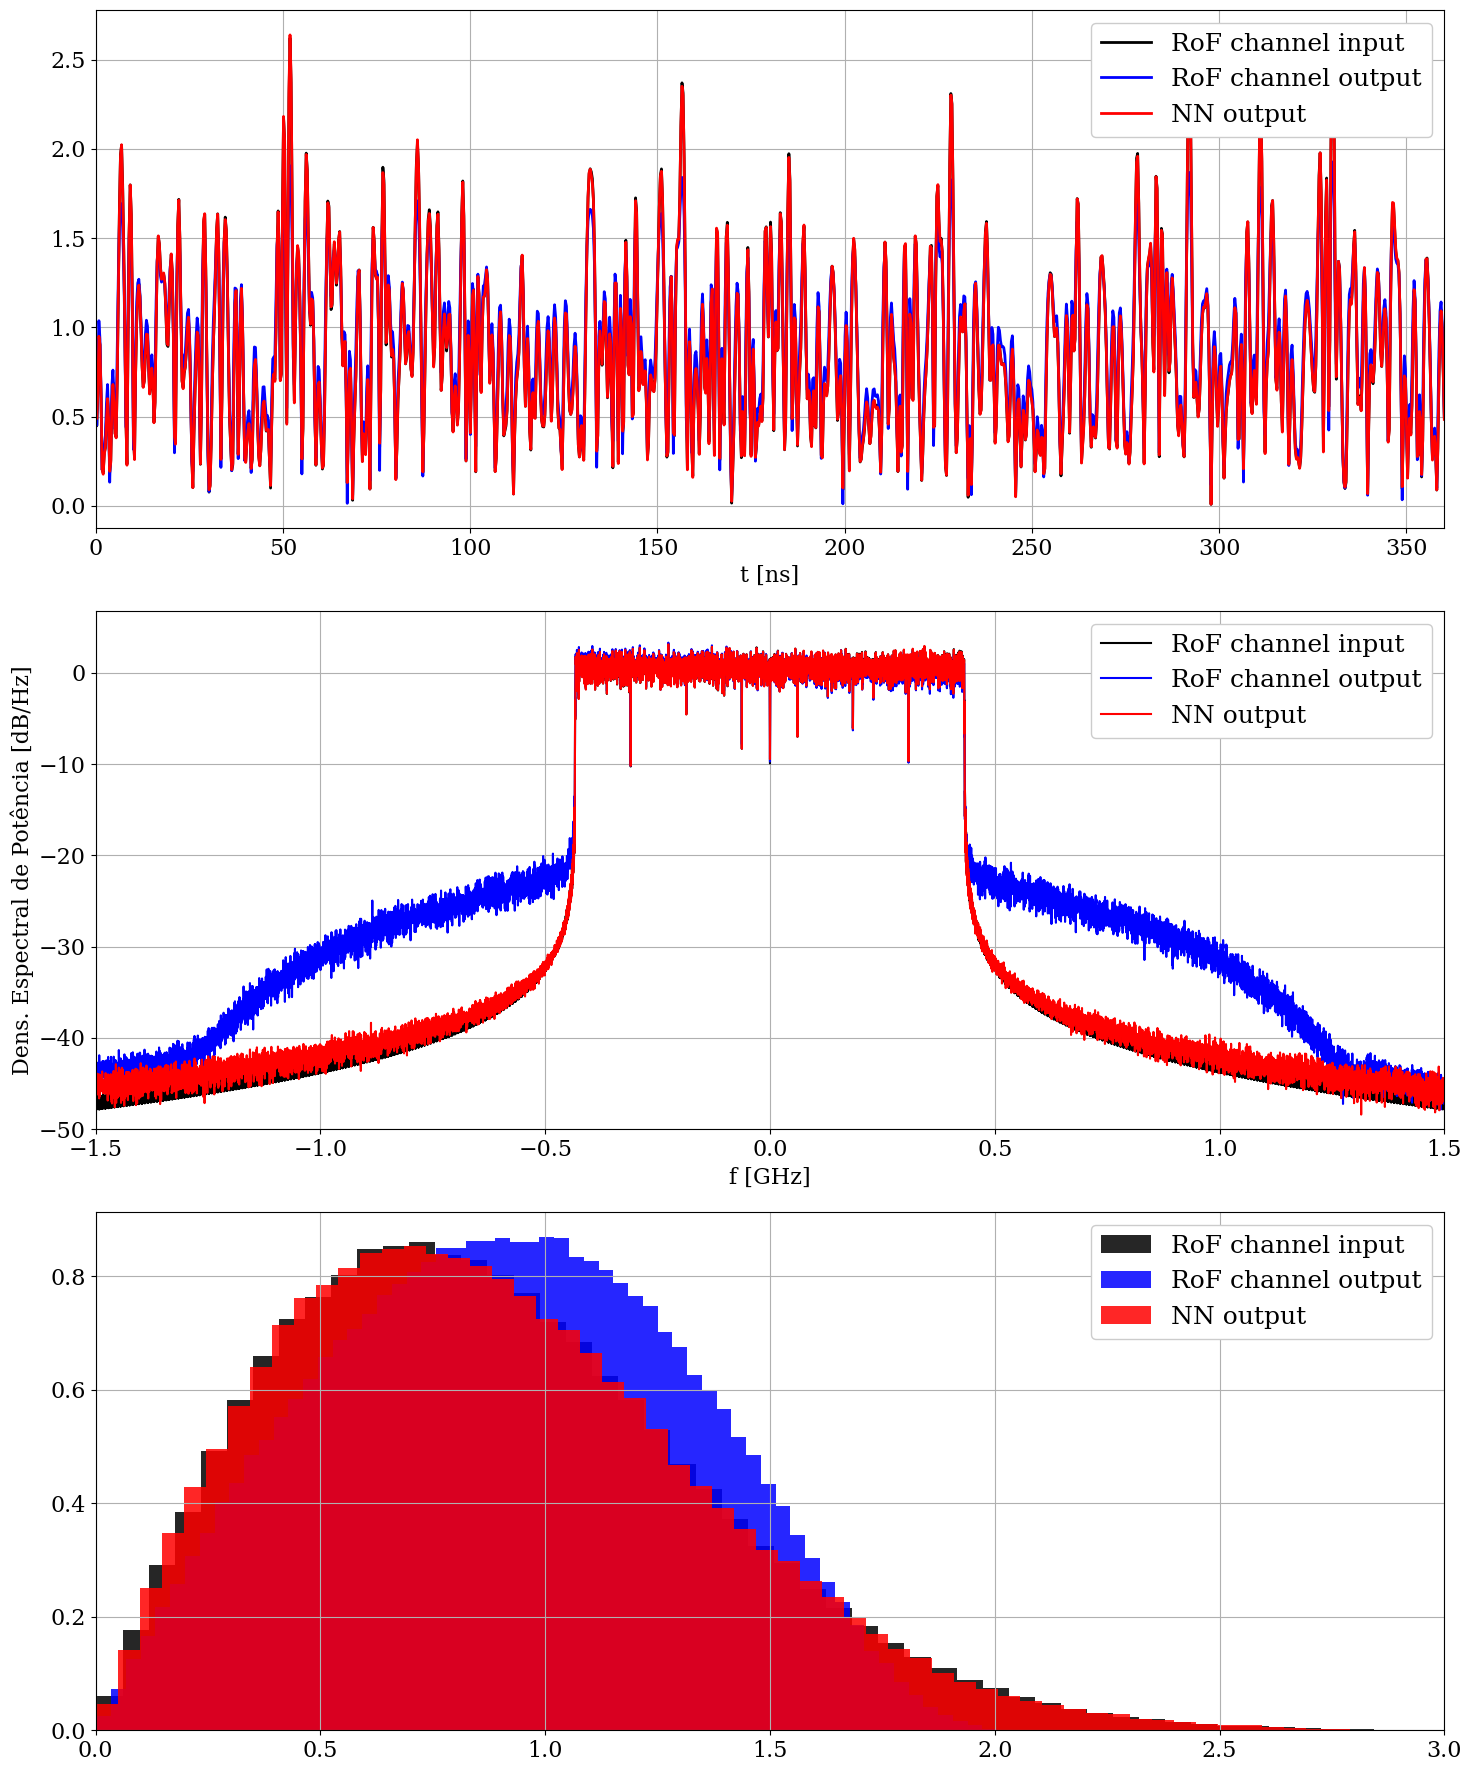

In [155]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

MSE = 10*th.log10(th.mean(th.abs(sigRef - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), lw = 2, color = "k", label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), lw = 2, color = "b", label = "RoF channel output")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sig_nn.cpu().numpy()[indx]), lw = 2, color = "r", label = "NN output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "RoF channel output")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "NN output")

axs[0].set_xlim(0, np.max(t.cpu().numpy()[indx])*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, color = "k", label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, color = "b", label = 'RoF channel output', alpha = 0.85)
axs[2].hist(th.abs(sig_nn).detach().cpu().numpy(), density = True, bins = 64, color = "r",label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

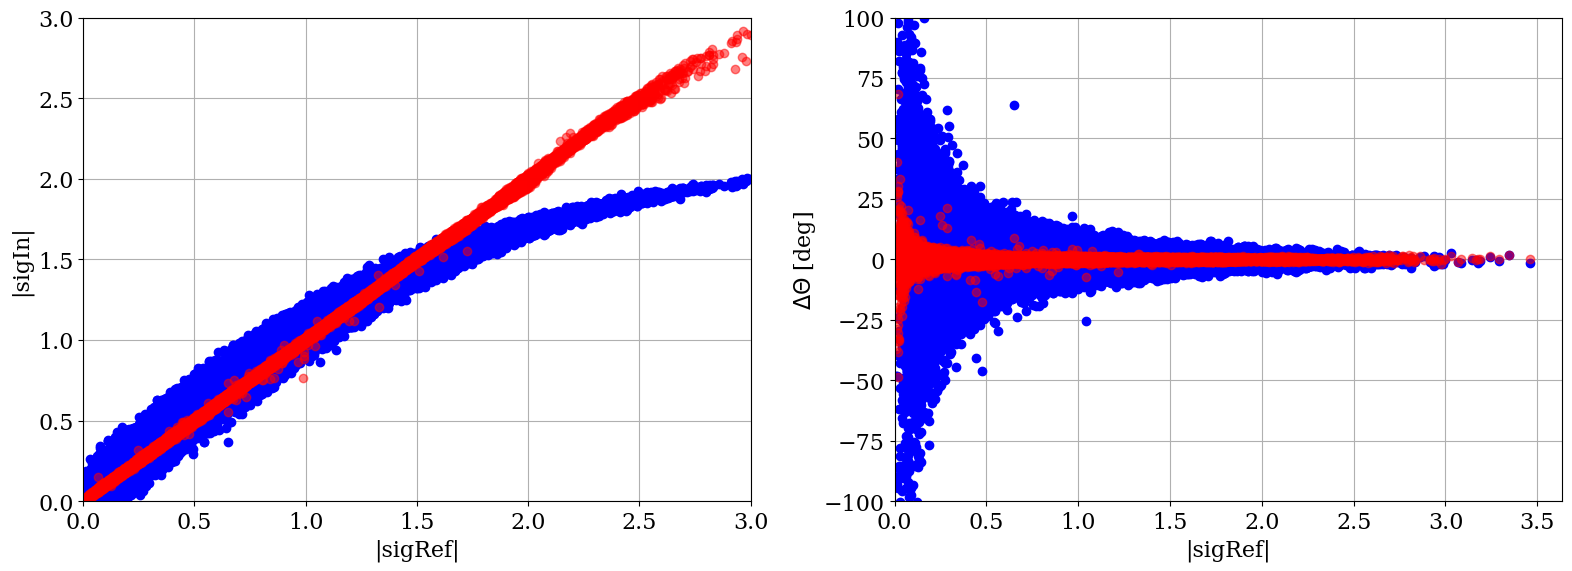

In [156]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), np.abs(sigIn[0:n_pts].detach().cpu().numpy()), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), np.abs(sig_nn[0:n_pts].detach().cpu().numpy()), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), (np.angle(sigIn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), (np.angle(sig_nn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()


### 5 Arquitetura de Aprendizado Direto

In [157]:
paramDLA = parameters()

N = 100_000

paramDLA.divByL = 1
paramDLA.trainTestFrac = 0.75
paramDLA.batch_size = 1_000
paramDLA.shuffle = False
paramDLA.includeMemory = includeMemory
paramDLA.Ntaps = 2
paramDLA.K = 2
paramDLA.augment = True

paramDLA.layers = [(paramDLA.K + 2)*paramDLA.Ntaps, 35, 2]

paramDLA.device = device
paramDLA.lr = 5e-3
paramDLA.epochs = 500
paramDLA.activation = "relu"
paramDLA.pgrsBar = True
paramDLA.directLearn = True
paramDLA.RoFChannel_model = RoFChannel_model

paramDLA.envelope = False

DPD_directLearn, trainLoss, testLoss = NN_training(sigIn[0:N], sigRef[0:N], paramDLA)

  0%|          | 0/500 [00:00<?, ?it/s]

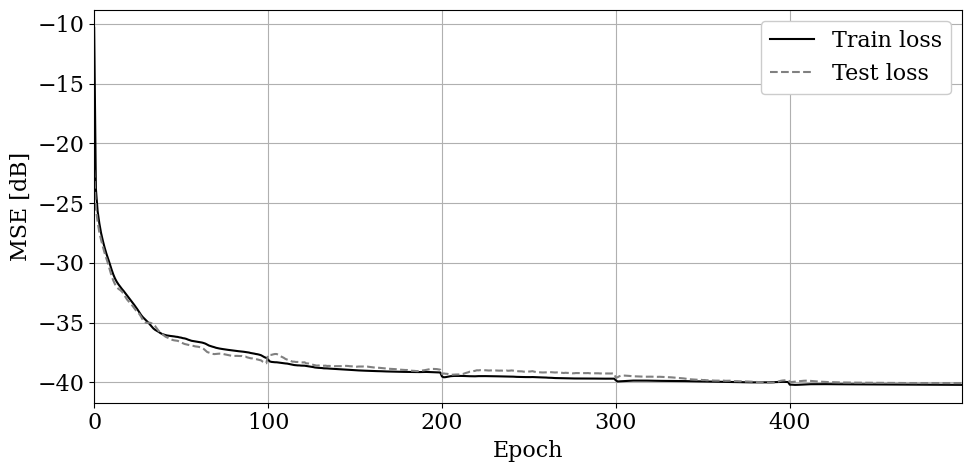

In [158]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramDLA.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [159]:
if includeMemory:
    sig_nn = fitFilterNN(sigRef, DPD_directLearn, paramDLA.Ntaps, paramDLA.K, 1, 100, augment = paramDLA.augment)
    sig_nn = fitFilterNN(sig_nn, RoFChannel_model, paramRoF.Ntaps, paramRoF.K, 1, 100)
else:
    with th.no_grad():
        sig_nn = th.view_as_complex(DPD_directLearn(th.view_as_real(sigIn).to(th.float32)))

MSE = -37.719 dB


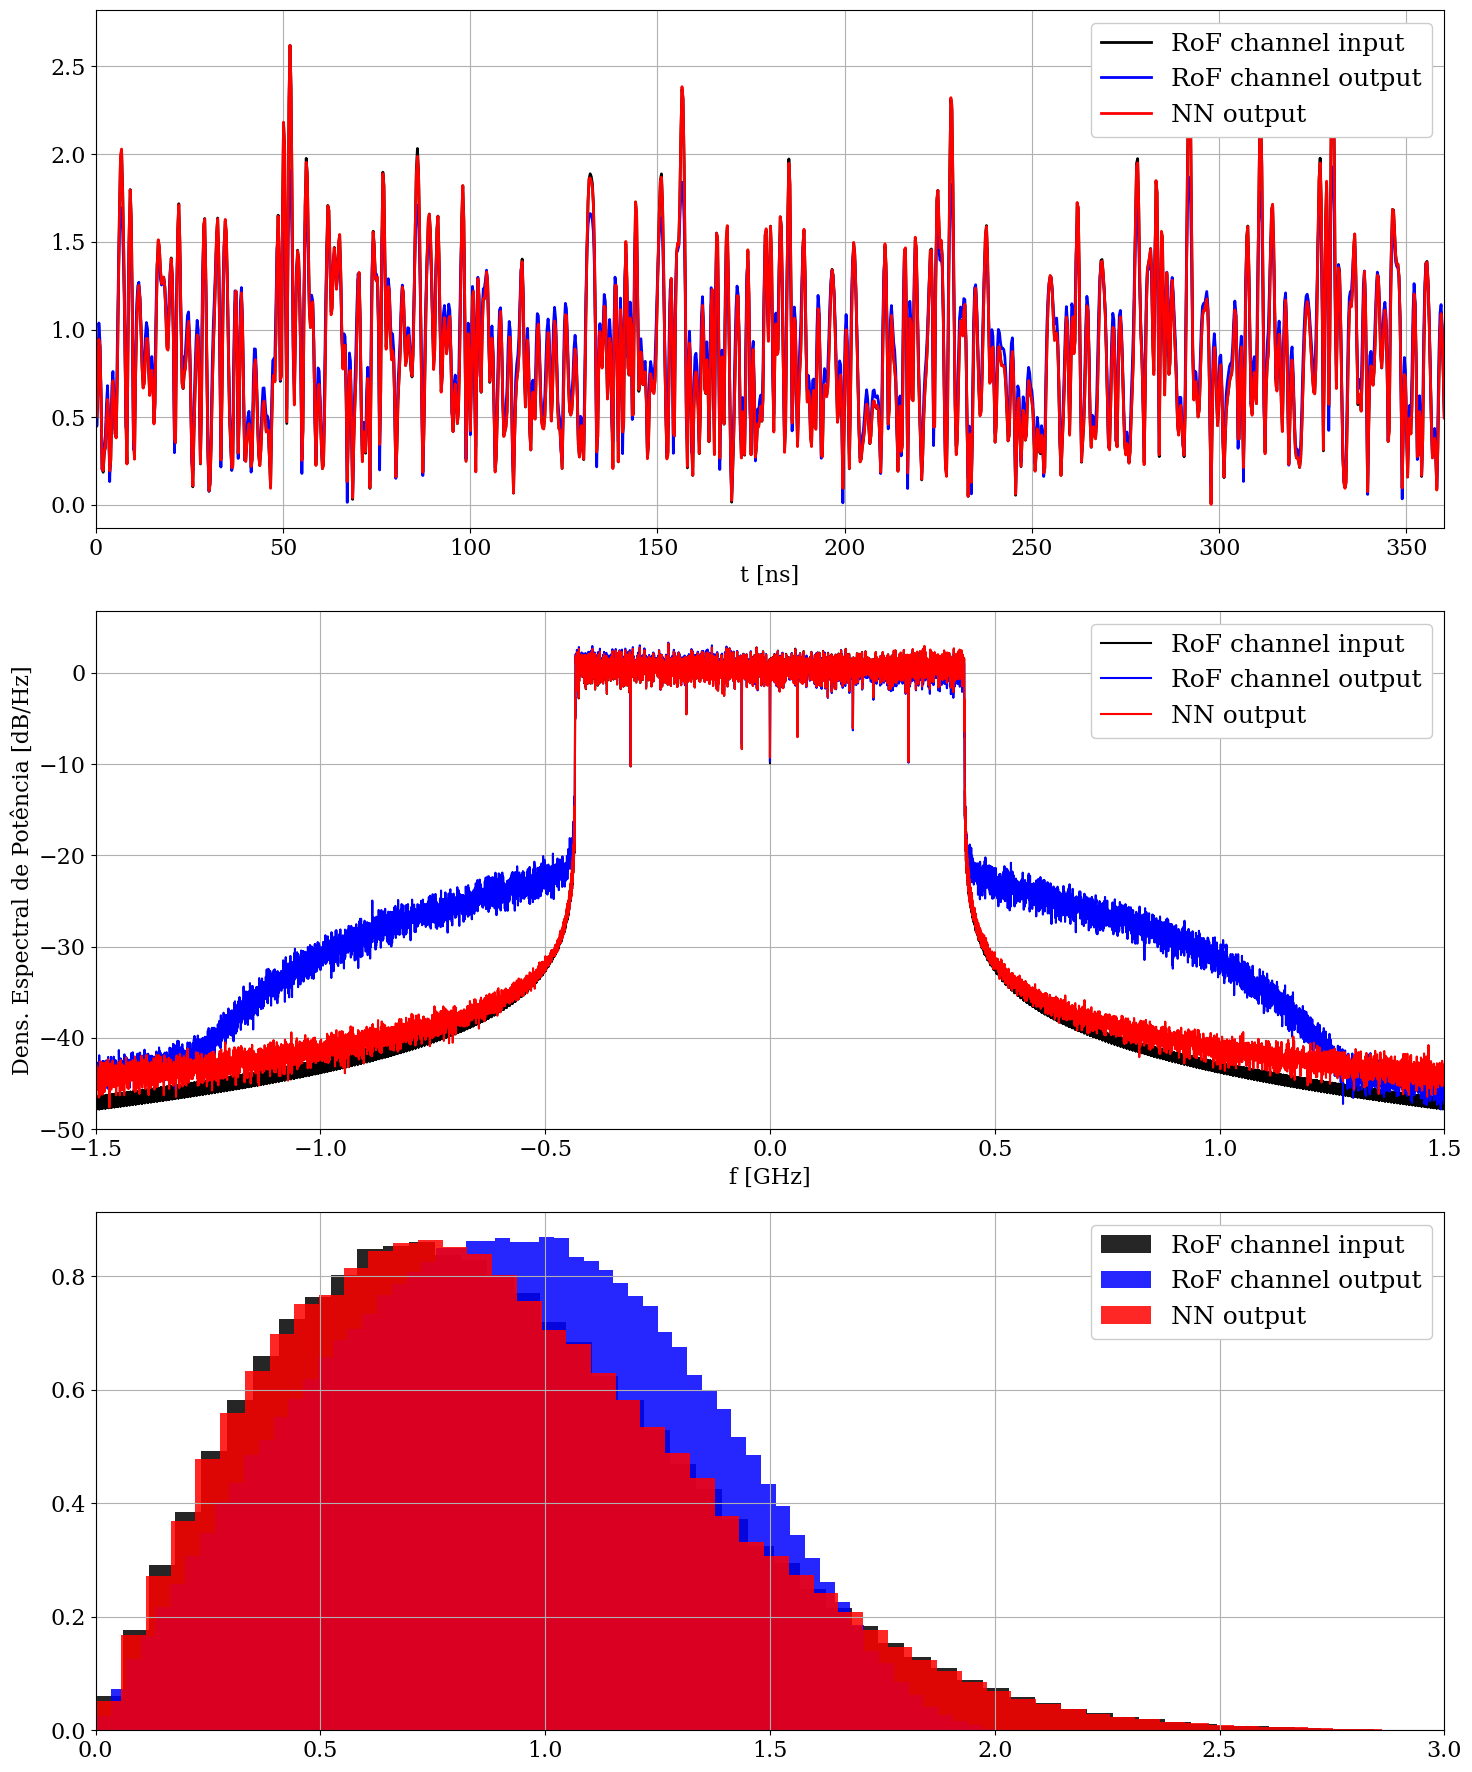

In [160]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

MSE = 10*th.log10(th.mean(th.abs(sigRef - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), lw = 2, color = "k", label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), lw = 2, color = "b", label = "RoF channel output")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sig_nn.cpu().numpy()[indx]), lw = 2, color = "r", label = "NN output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "RoF channel output")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "NN output")

axs[0].set_xlim(0, np.max(t.cpu().numpy()[indx])*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, color = "k", label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, color = "b", label = 'RoF channel output', alpha = 0.85)
axs[2].hist(th.abs(sig_nn).detach().cpu().numpy(), density = True, bins = 64, color = "r",label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

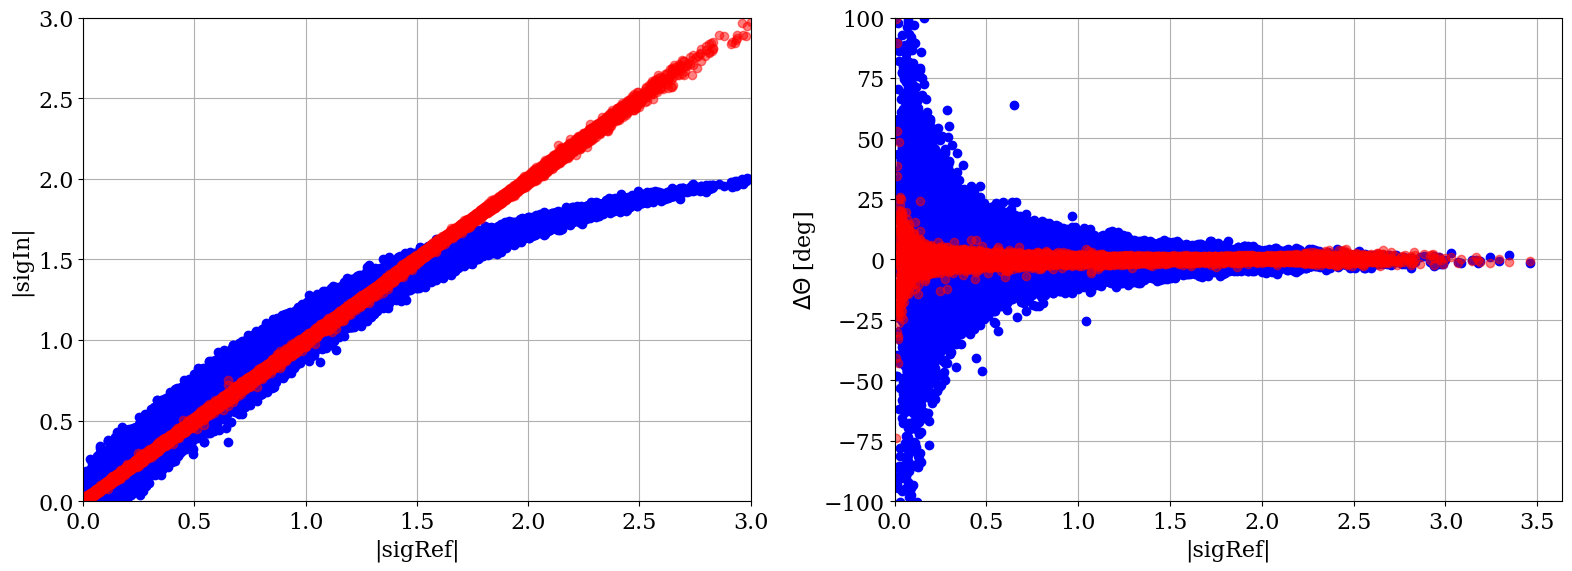

In [161]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), np.abs(sigIn[0:n_pts].detach().cpu().numpy()), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), np.abs(sig_nn[0:n_pts].detach().cpu().numpy()), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), (np.angle(sigIn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts].detach().cpu().numpy()), (np.angle(sig_nn.detach().cpu().numpy()) - np.angle(sigRef.detach().cpu().numpy()))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()


### 6 - DPD Test

In [162]:
# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                 # Tam. da FFT
paramOFDM.G    = 32                   # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS_nn

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 100
np.random.seed(3)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [163]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

# ILA
DPD_indirectLearn.eval()
sigTx_DPD_ILA = fitFilterNN(th.from_numpy(sigTx.copy()).to(device).type(th.complex64), DPD_indirectLearn, paramILA.Ntaps, paramILA.K, 1, 100, augment = paramILA.augment)

# DLA
DPD_directLearn.eval()
sigTx_DPD_DLA = fitFilterNN(th.from_numpy(sigTx.copy()).to(device).type(th.complex64), DPD_directLearn, paramDLA.Ntaps, paramDLA.K, 1, 4000, augment = True)

sigTx_DPD_ILA = sigTx_DPD_ILA.detach().cpu().numpy()
sigTx_DPD_DLA = sigTx_DPD_DLA.detach().cpu().numpy()

In [164]:
gain_DLA = np.sqrt(signal_power(sigTx_DPD_DLA))
gain_ILA = np.sqrt(signal_power(sigTx_DPD_ILA))

In [165]:
numtaps = 4096
h_dpd = firwin(numtaps, 2*Rs, fs = Fs)

sigTx_DPD_ILA = upsample(sigTx_DPD_ILA.ravel(), SpS//SpS_nn).reshape(-1,) 
sigTx_DPD_ILA = firFilter(h_dpd, sigTx_DPD_ILA)
sigTx_DPD_ILA = pnorm(sigTx_DPD_ILA)

sigTx_DPD_DLA = upsample(sigTx_DPD_DLA.ravel(), SpS//SpS_nn).reshape(-1,) 
sigTx_DPD_DLA = firFilter(h_dpd, sigTx_DPD_DLA)
sigTx_DPD_DLA = pnorm(sigTx_DPD_DLA)

t = np.arange(0, sigTx_DPD_ILA.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [166]:
sigTx_RF_ILA = np.real( sigTx_DPD_ILA * gain_ILA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_ILA *= gain_pre_MZM
sigTx_RF_ILA = np.clip(sigTx_RF_ILA, -paramMZM.Vpi/2, paramMZM.Vpi/2)

sigTx_RF_DLA = np.real( sigTx_DPD_DLA * gain_DLA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_DLA *= gain_pre_MZM
sigTx_RF_DLA = np.clip(sigTx_RF_DLA, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input with ILA-DPD: {10*np.log10(1e3*signal_power(sigTx_RF_ILA)):.3f} dBm")
print(f"Power at MZM's input with DLA-DPD: {10*np.log10(1e3*signal_power(sigTx_RF_DLA)):.3f} dBm")

Power at MZM's input with ILA-DPD: 17.651 dBm
Power at MZM's input with DLA-DPD: 17.628 dBm


#### 6.2 Sinal óptico

In [167]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_ILA.size)
sigTxo_ILA = mzm(Ai, sigTx_RF_ILA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_ILA = np.sqrt(signal_power(sigTxo_ILA))*pnorm(firFilter(hopt_tx, sigTxo_ILA))

sigRxo_ILA = linearFiberChannel(sigTxo_ILA, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo_ILA)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo_ILA)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


In [168]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_DLA.size)
sigTxo_DLA = mzm(Ai, sigTx_RF_DLA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_DLA = np.sqrt(signal_power(sigTxo_DLA))*pnorm(firFilter(hopt_tx, sigTxo_DLA))

sigRxo_DLA = linearFiberChannel(sigTxo_DLA, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo_DLA)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo_DLA)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


#### 6.3 Sinal elétrico (fotocorrente)

In [169]:
I_Rx_ILA = photodiode(sigRxo_ILA, paramPD)
I_Rx_ILA -= I_Rx_ILA.mean()

In [170]:
I_Rx_DLA = photodiode(sigRxo_DLA, paramPD)
I_Rx_DLA -= I_Rx_DLA.mean()

#### 6.4 Sinal elétrico pós-FPF

In [171]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF_ILA = firFilter(hbp_RF, I_Rx_ILA)
I_RF_DLA = firFilter(hbp_RF, I_Rx_DLA)

#### 6.5 Sinal elétrico pós-PA

In [172]:
sigRx_ILA = hilbert(I_RF_ILA)*np.exp(-1j*2*pi*paramRF.fc_e*t)

sigRx_ILA = sigRx_ILA.real + 1j*sigRx_ILA.imag * IQ_imb
sigRx_ILA *= gain_pre_PA

print(f"Power at PA's input: {10*np.log10(1e3*signal_power(sigRx_ILA)):.3f} dB")

sigRx_ILA = power_amplifier(sigRx_ILA)
sigRx_PA_DPD_ILA = sigRx_ILA.copy()
sigRx_PA_DPD_ILA = pnorm(sigRx_PA_DPD_ILA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx_ILA = firFilter(hlp, sigRx_ILA)

delay = finddelay(sigRx_ILA, sigTx_DPD_ILA)
sigRx_ILA = np.roll(sigRx_ILA, -delay)

rot = np.mean(sigTx_DPD_ILA/sigRx_ILA)
sigRx_ILA = rot/np.abs(rot)*sigRx_ILA

Power at PA's input: 5.459 dB


In [173]:
sigRx_DLA = hilbert(I_RF_DLA)*np.exp(-1j*2*pi*paramRF.fc_e*t)

sigRx_DLA = sigRx_DLA.real + 1j*sigRx_DLA.imag * IQ_imb
sigRx_DLA *= gain_pre_PA

print(f"Power at PA's input: {10*np.log10(1e3*signal_power(sigRx_DLA)):.3f} dB")

sigRx_DLA = power_amplifier(sigRx_DLA)
sigRx_PA_DPD_DLA = sigRx_DLA.copy()
sigRx_PA_DPD_DLA = pnorm(sigRx_PA_DPD_DLA)

sigRx_PA_DPD_DLA = sigRx_DLA.copy()

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx_DLA = firFilter(hlp, sigRx_DLA)

delay = finddelay(sigRx_DLA, sigTx_DPD_DLA)
sigRx_DLA = np.roll(sigRx_DLA, -delay)

rot = np.mean(sigTx_DPD_DLA/sigRx_DLA)
sigRx_DLA = rot/np.abs(rot)*sigRx_DLA

Power at PA's input: 5.428 dB


#### Perfomance

In [174]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

paramOFDM.returnChannel = True

symbRx_OFDM = decimate(sigRx_ILA.copy(), paramDec).ravel()
symbRx_DPD_ILA, H1 = demodulateOFDM(symbRx_OFDM, paramOFDM)

symbRx_OFDM = decimate(sigRx_DLA.copy(), paramDec).ravel()
symbRx_DPD_DLA, H2 = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00000 
SNR = 30.164 dB 
EVM = 3.104 %


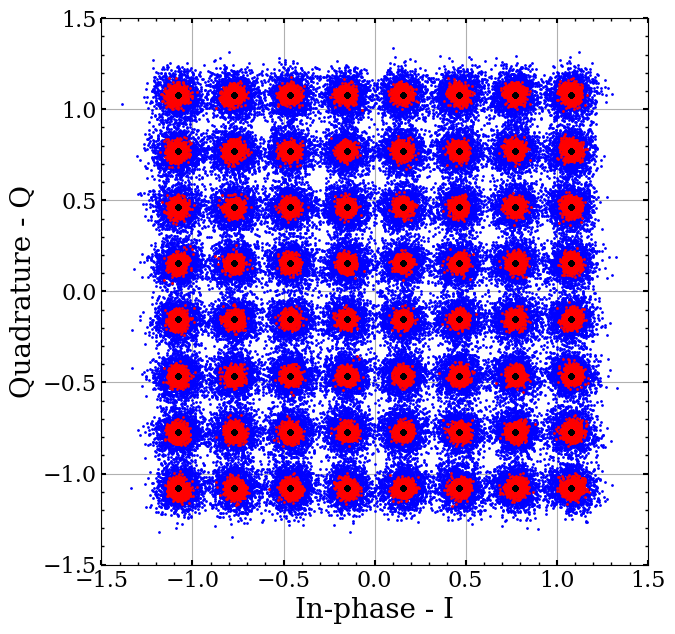

In [175]:
discard = Ni
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_DLA[index], symbTx[index], modOrder, modType)

EVM = np.sqrt(calcEVM(symbRx_DPD_DLA[index], modOrder, modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_DLA = pnorm(symbRx_DPD_DLA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1, label = "No DPD")
axs.plot(symbRx_DPD_DLA[index].real, symbRx_DPD_DLA[index].imag, "o", color = "r", ms = 1, label = "NN-DPD")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

BER = 0.00000 
SNR = 30.944 dB 
EVM = 2.838 %


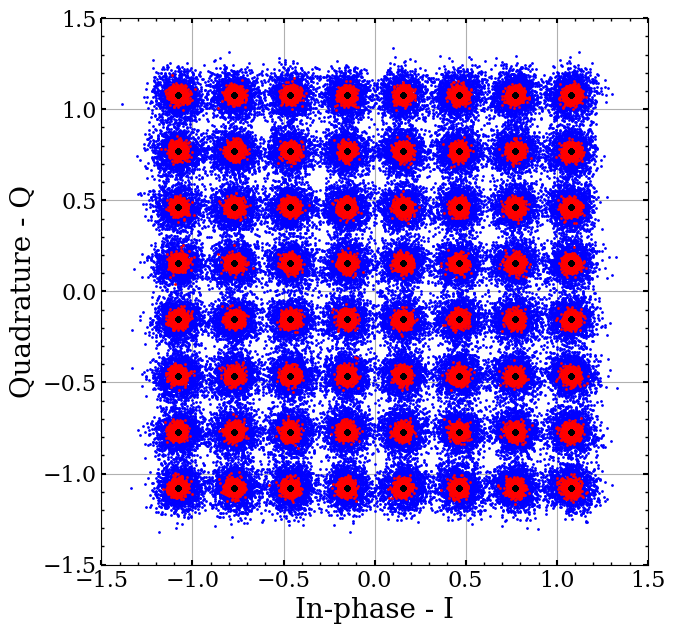

In [176]:
discard = Ni
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_ILA[index], symbTx[index], modOrder, modType)

EVM = np.sqrt(calcEVM(symbRx_DPD_ILA[index], modOrder, modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_ILA = pnorm(symbRx_DPD_ILA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1, label = "No DPD")
axs.plot(symbRx_DPD_ILA[index].real, symbRx_DPD_ILA[index].imag, "o", color = "r", ms = 1, label = "NN-DPD")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

In [177]:
freq, P_sigTx            = welch(pnorm(sigTx), fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA         = welch(pnorm(sigRx_PA)[0::SpS//SpS_nn], fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_DLA = welch(pnorm(sigRx_PA_DPD_DLA)[0::SpS//SpS_nn], fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_ILA = welch(pnorm(sigRx_PA_DPD_ILA)[0::SpS//SpS_nn], fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -34.643 dB
SigRx PA w/o DPD - ACLR = -25.315 dB
SigRx PA w DPD-ILA - ACLR = -30.636 dB
SigRx PA w DPD-DLA - ACLR = -30.882 dB


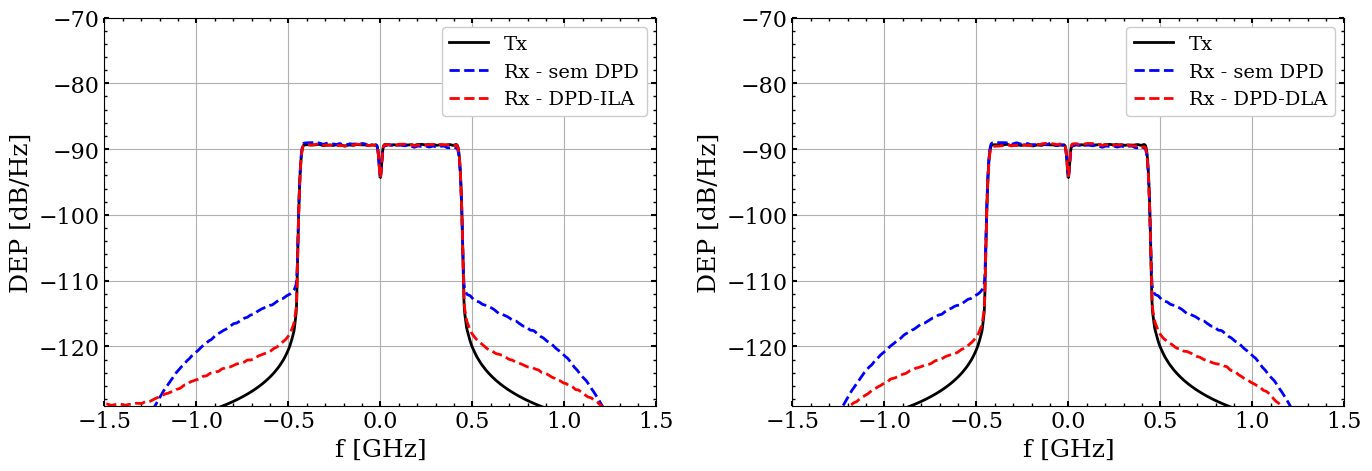

In [178]:
print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-ILA - ACLR = {calcACLR(P_sigRx_PA_DPD_ILA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-DLA - ACLR = {calcACLR(P_sigRx_PA_DPD_DLA, freq, 0.5e9):.3f} dB")

fig, axs = plt.subplots(1, 2, figsize = (14, 5))

axs[0].plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_ILA), lw = 2, color = "r", label = "Rx - DPD-ILA", ls = "--")
axs[0].set_xlim(-1.5, 1.5)
axs[0].set_ylim(-129, -70)

axs[0].set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs[0].set_xlabel("f [GHz]", fontsize = 18)
axs[0].legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()

axs[1].plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_DLA), lw = 2, color = "r", label = "Rx - DPD-DLA", ls = "--")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-129, -70)

axs[1].set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs[1].set_xlabel("f [GHz]", fontsize = 18)
axs[1].legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")